In [23]:
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Загрузка и обработка данных

In [24]:
df = pd.read_csv('data/ds_salaries.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [25]:
# задаём уровень значимости
alpha = 0.05
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


### Описательный анализ данных

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


В датасете 607 записей, без пропусков значений.

Типы данных столбцов корректны.

Проверим данные на наличие дубликатов:

In [27]:
print(f'Количество дубликатов: {df[df.duplicated()].shape[0]}')

Количество дубликатов: 0


В датасете дубликаты отсутствуют.

Среди признаков видим признаки salary и salary_currency, при этом в датасете присутствует признак salary_in_usd.
Для проведения сравнительного анализа зарплат, будет достаточно одного признака - salary_in_usd, признаки salary и salary_currency можно удалить.

In [28]:
df = df.drop(['salary', 'salary_currency', 'Unnamed: 0'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary_in_usd       607 non-null    int64 
 5   employee_residence  607 non-null    object
 6   remote_ratio        607 non-null    int64 
 7   company_location    607 non-null    object
 8   company_size        607 non-null    object
dtypes: int64(3), object(6)
memory usage: 42.8+ KB


In [33]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


Классифицируем признаки на числовые и категориальные:

- work_year - числовой признак
- experience_level, employment_type, company_size - категориальные признаки
- remote_ratio - числовой (дискретный)
- job_title - категориальный признак
- salary_in_usd - числовой признак
- employee_residence, company_location - категориальные признаки

Найдем основные статистические характеристики для каждого из признаков

Для числовых признаков:

In [29]:
df.describe()

,work_year,salary_in_usd,remote_ratio
count,607.000000,607.000000,607.00000
mean,2021.405272,112297.869852,70.92257
std,0.692133,70957.259411,40.70913
min,2020.000000,2859.000000,0.00000
25%,2021.000000,62726.000000,50.00000
50%,2022.000000,101570.000000,100.00000
75%,2022.000000,150000.000000,100.00000
max,2022.000000,600000.000000,100.00000


Для категориальных:

In [30]:
df.describe(include=['object', 'category'])

,experience_level,employment_type,job_title,employee_residence,company_location,company_size
count,607,607,607,607,607,607
unique,4,4,50,57,50,3
top,SE,FT,Data Scientist,US,US,M
freq,280,588,143,332,355,326


## 2. Разведывательный анализ данных

Проведем базовый анализ для каждого признака, участвующего в исследовании.

для числовых признаков построим гистограммы, иллюстрирующие распределения:

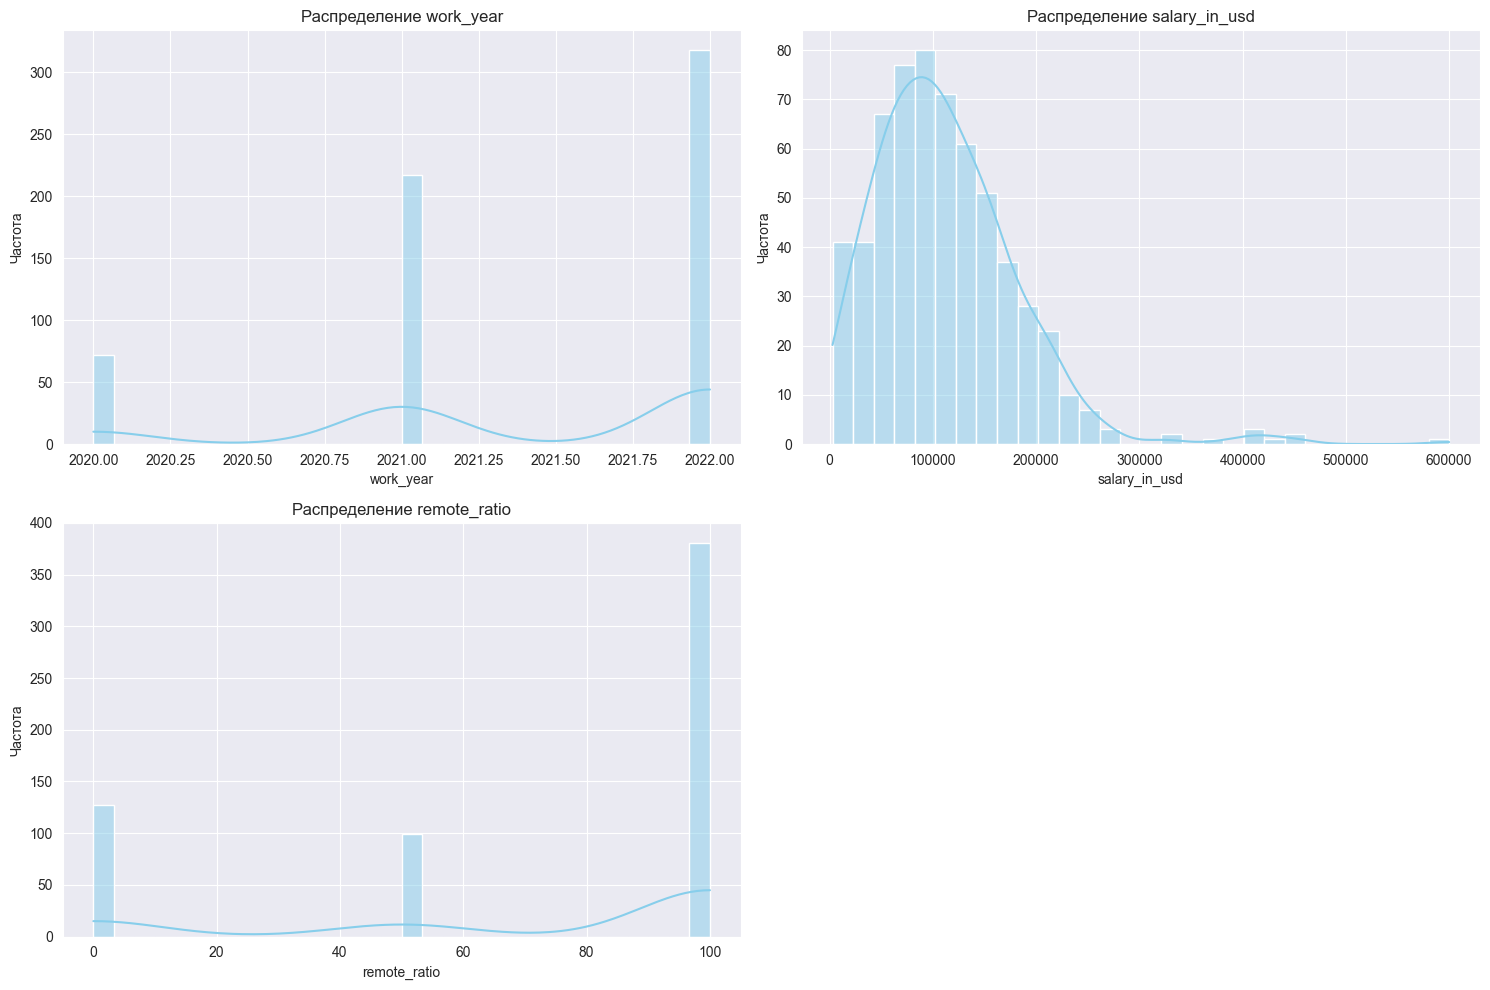

In [38]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)  # 2 строки, 2 столбца (или поменяй, если нужно больше)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')

# plt.subplot(2, 2, i)  # 2 строки, 2 столбца (или поменяй, если нужно больше)
# sns.histplot(df['salary_in_usd'], kde=True, bins=30, color='skyblue')
# plt.title(f'Распределение salary_in_usd')
# plt.xlabel(col)
# plt.ylabel('Частота')

plt.tight_layout()
plt.show()

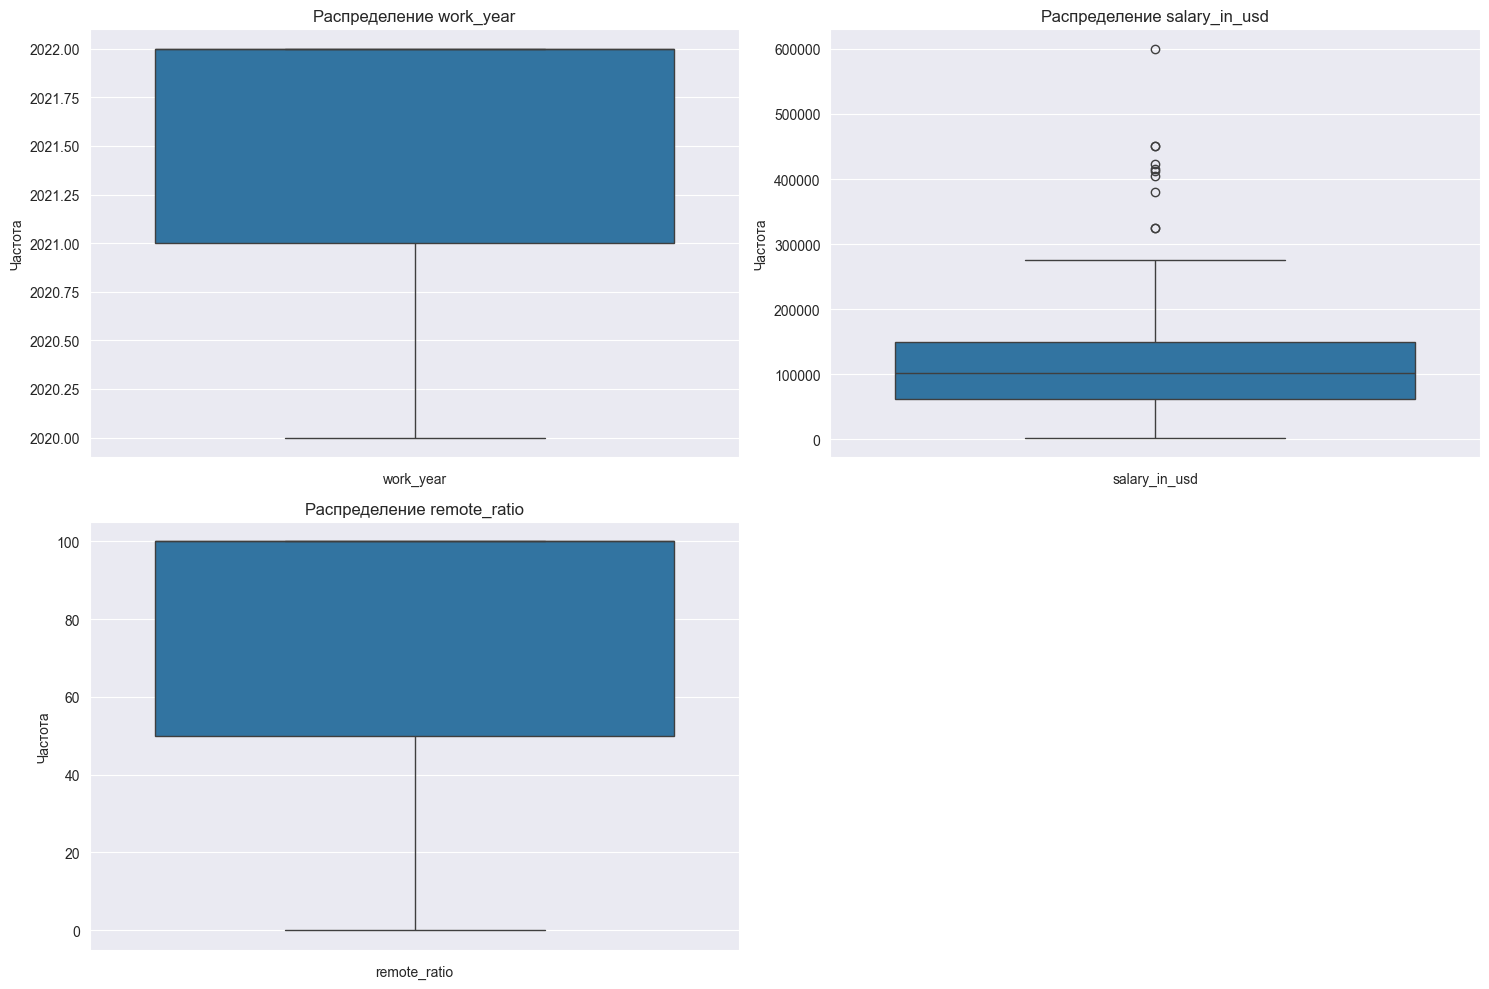

In [40]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)  # 2 строки, 2 столбца (или поменяй, если нужно больше)
    sns.boxplot(df[col])
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')

# plt.subplot(2, 2, i)  # 2 строки, 2 столбца (или поменяй, если нужно больше)
# sns.histplot(df['salary_in_usd'], kde=True, bins=30, color='skyblue')
# plt.title(f'Распределение salary_in_usd')
# plt.xlabel(col)
# plt.ylabel('Частота')

plt.tight_layout()
plt.show()